# This is a demonstration of Synthesizer
## What is Grid object?

In [15]:
from synthesizer import GRID_DIR
print(GRID_DIR)

/Users/jiaheak/Library/Application Support/Synthesizer/grids


In [16]:
import matplotlib.pyplot as plt
import numpy as np
from synthesizer import Grid
# Return to the unmodified grid
grid = Grid("test_grid")

log10age = 6.0  # log10(age/yr)
Z = 0.01  # metallicity
grid_point = grid.get_grid_point(log10ages=log10age, metallicities=Z)

Text(0, 0.5, '$\\rm log_{10}(L_{\\nu}/erg\\ s^{-1}\\ Hz^{-1} M_{\\odot}^{-1})$')

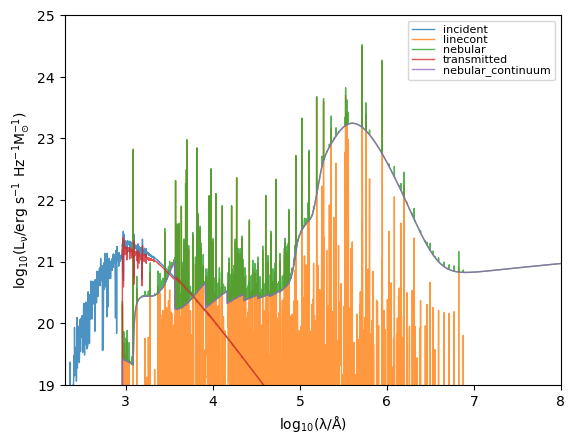

In [17]:
for spectra_type in grid.available_spectra:
    # Get `Sed` object
    sed = grid.get_sed_at_grid_point(grid_point, spectra_type=spectra_type)

    # Mask zero valued elements
    mask = sed.lnu > 0
    plt.plot(
        np.log10(sed.lam[mask]),
        np.log10(sed.lnu[mask]),
        lw=1,
        alpha=0.8,
        label=spectra_type,
    )

plt.legend(fontsize=8, labelspacing=0.0)
plt.xlim(2.3, 8)
plt.ylim(19, 25)
plt.xlabel(r"$\rm log_{10}(\lambda/\AA)$")
plt.ylabel(r"$\rm log_{10}(L_{\nu}/erg\ s^{-1}\ Hz^{-1} M_{\odot}^{-1})$")

# Galaxies & Components
## Particle Stars

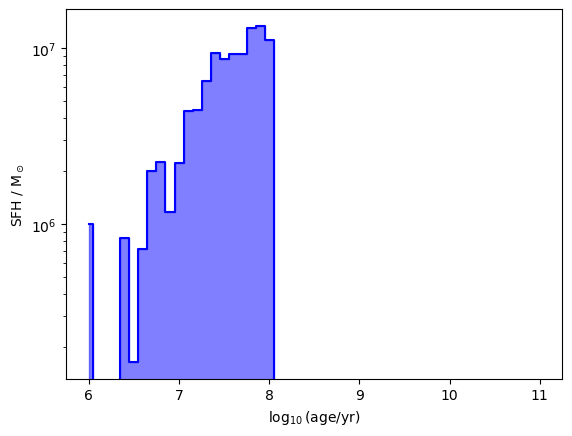

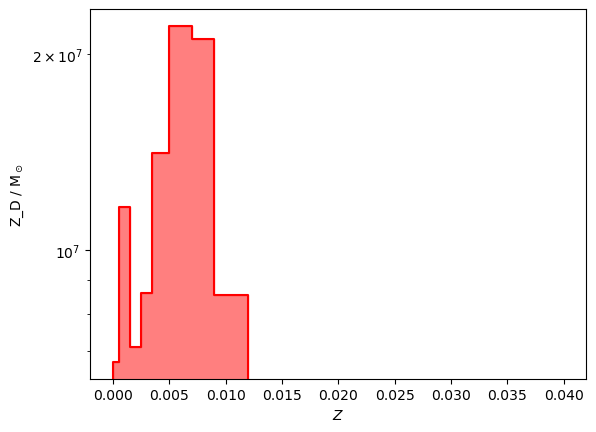

(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel='$Z$', ylabel='Z_D / M$_\\odot$'>)

In [24]:
from synthesizer.particle import Stars, Gas, BlackHoles, Galaxy
from unyt import Myr, Msun, Mpc, yr

N = 100
ages = np.random.rand(N) * 100 * Myr
metallicities = np.random.rand(N) / 100
initial_masses = np.ones(N) * 1e6 * Msun

stars = Stars(
    initial_masses=initial_masses,
    ages=ages,
    metallicities=metallicities,
)

stars.plot_sfh(grid.log10ages)
stars.plot_metal_dist(grid.metallicities)

In [22]:
gas = Gas(
    masses=np.ones(1000) * 10**6 * Msun,
    metallicities=np.random.rand(1000) * 0.02,
    dust_to_metal_ratio=0.25,
    coordinates=np.random.rand(1000, 3) * 1 * Mpc,
    centre=np.mean(np.random.rand(1000, 3) * 1, axis=0) * Mpc,
    hii_mass=np.random.rand(1000) * 1e4 * Msun,
    hii_metallicity=np.random.rand(1000) * 0.02,
)
print(gas)

+---------------------------------------------------------------------------------------+
|                                          GAS                                          |
+--------------------------------+------------------------------------------------------+
| Attribute                      | Value                                                |
+--------------------------------+------------------------------------------------------+
| nparticles                     | 1000                                                 |
+--------------------------------+------------------------------------------------------+
| metallicity_floor              | 1.00e-05                                             |
+--------------------------------+------------------------------------------------------+
| name                           | 'Gas'                                                |
+--------------------------------+------------------------------------------------------+
| componen

In [25]:
# Make fake properties
n = 4
masses = 10 ** np.random.uniform(low=7, high=9, size=n) * Msun
coordinates = np.random.normal(0, 1.5, (n, 3)) * Mpc
accretion_rates = 10 ** np.random.uniform(low=-2, high=1, size=n) * Msun / yr
metallicities = np.full(n, 0.01)

# And get the black holes object
bh = BlackHoles(
    masses=masses,
    coordinates=coordinates,
    accretion_rates=accretion_rates,
    metallicities=metallicities,
)

## parametric Star Formation History

/Users/jiaheak/miniforge3/envs/galaxy_synthesis_env/lib/python3.14/site-packages/synthesizer/parametric/sf_hist.py:836: RuntimeWarning: divide by zero encountered in power
  term2 = (ages[mask] / self.peak_age) ** self.beta


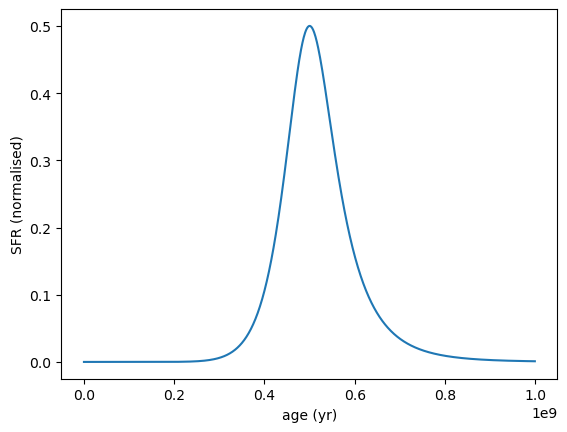

In [26]:
from unyt import yr
from synthesizer.parametric import SFH

sfh = SFH.DoublePowerLaw(
    peak_age=5e8 * yr, alpha=10, beta=-10, max_age=1e9 * yr
)

sfh.plot_sfh(t_range=(0, 1e9))

# Emissions


In [27]:
from unyt import Angstrom, Hz, erg, eV, s, um
from synthesizer import Sed

# Define some wavelengths and luminosities densities
lams = np.logspace(3, 5, 100) * Angstrom
lnus = np.logspace(26, 30, 100) * erg / (s * Hz)

# Create a Sed object
sed = Sed(lams, lnus)

In [28]:
print(sed.wavelength)
print(sed.luminosity_nu)

[  1000.           1047.61575279   1097.49876549   1149.7569954
   1204.50354026   1261.85688307   1321.94114847   1384.88637139
   1450.8287785    1519.91108295   1592.28279334   1668.1005372
   1747.52840001   1830.7382803    1917.91026167   2009.23300257
   2104.90414451   2205.1307399    2310.12970008   2420.12826479
   2535.36449397   2656.08778295   2782.55940221   2915.05306283
   3053.85550883   3199.2671378    3351.60265094   3511.19173422
   3678.37977183   3853.52859371   4037.0172586    4229.24287439
   4430.62145758   4641.58883361   4862.60158007   5094.13801482
   5336.69923121   5590.81018251   5857.02081806   6135.90727341
   6428.07311728   6734.15065775   7054.80231072   7390.72203353
   7742.63682681   8111.3083079    8497.53435909   8902.15085445
   9326.03346883   9770.09957299  10235.31021899  10722.6722201
  11233.24032978  11768.11952435  12328.46739442  12915.49665015
  13530.4777458   14174.74162927  14849.68262254  15556.7614393
  16297.50834621  17073.52647

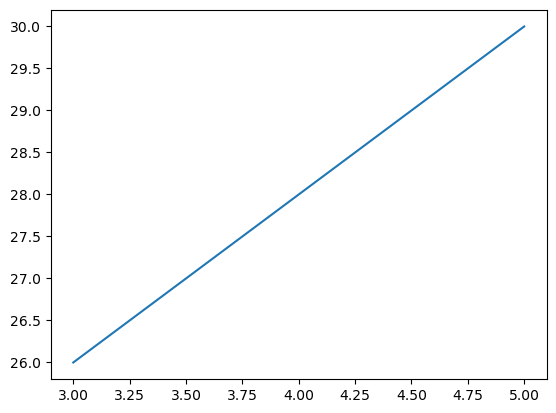

In [29]:
plt.plot(np.log10(sed.lam), np.log10(sed.lnu))
plt.show()

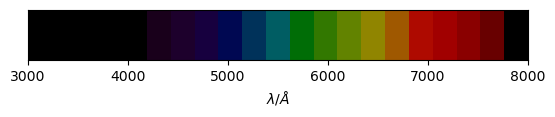

In [30]:
fig, ax = sed.plot_spectra_as_rainbow()

In [31]:
from synthesizer.emission_models.attenuation import PowerLaw

sed4_att = sed4.apply_attenuation(tau_v=0.7, dust_curve=PowerLaw(-1.0))

# Integrate the multidimensional spectra
int_sed4 = sed4.sum()
int_sed4_att = sed4_att.sum()

fig, ax = int_sed4.plot_spectra(label="Original")
fig, ax = int_sed4_att.plot_spectra(label="Attenuated", fig=fig, ax=ax)

NameError: name 'sed4' is not defined